In [9]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
!unzip /content/drive/MyDrive/Dataset.zip -d /content/

Streaming output truncated to the last 5000 lines.
  inflating: /content/natural_images/cat/cat_0204.jpg  
  inflating: /content/natural_images/cat/cat_0205.jpg  
  inflating: /content/natural_images/cat/cat_0206.jpg  
  inflating: /content/natural_images/cat/cat_0207.jpg  
  inflating: /content/natural_images/cat/cat_0208.jpg  
  inflating: /content/natural_images/cat/cat_0209.jpg  
  inflating: /content/natural_images/cat/cat_0210.jpg  
  inflating: /content/natural_images/cat/cat_0211.jpg  
  inflating: /content/natural_images/cat/cat_0212.jpg  
  inflating: /content/natural_images/cat/cat_0213.jpg  
  inflating: /content/natural_images/cat/cat_0214.jpg  
  inflating: /content/natural_images/cat/cat_0215.jpg  
  inflating: /content/natural_images/cat/cat_0216.jpg  
  inflating: /content/natural_images/cat/cat_0217.jpg  
  inflating: /content/natural_images/cat/cat_0218.jpg  
  inflating: /content/natural_images/cat/cat_0219.jpg  
  inflating: /content/natural_images/cat/cat_0220.jpg

In [10]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import matplotlib.pyplot as plt

In [11]:
train_dir = "/content/natural_images"      # Updated path to the unzipped dataset root
validation_dir = "/content/natural_images" # Updated path to the unzipped dataset root

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest',
    validation_split=0.2 # Use 20% of data for validation
)

val_datagen = ImageDataGenerator(rescale=1./255, validation_split=0.2)

train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical',
    subset='training' # Specify training subset
)

validation_generator = val_datagen.flow_from_directory(
    validation_dir,
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical',
    subset='validation' # Specify validation subset
)

Found 5522 images belonging to 8 classes.
Found 1377 images belonging to 8 classes.


In [13]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import GlobalAveragePooling2D
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam

base_model = MobileNetV2(weights='imagenet', include_top=False, input_shape=(224,224,3))

# Freeze base model
base_model.trainable = False

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(256, activation='relu')(x)
x = Dropout(0.5)(x)
predictions = Dense(8, activation='softmax')(x)  # 8 classes

model = Model(inputs=base_model.input, outputs=predictions)

model.compile(optimizer=Adam(learning_rate=0.0001),
              loss='categorical_crossentropy',
              metrics=['accuracy'])

model.summary()

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 112, 112,  │        864 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 112, 112,  │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 112, 112,  │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 112, 112,  │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 112, 112,  │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 112, 112,  │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 113, 113,  │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 56, 56,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 56, 56,    │      2,304 │ block_1_depthwis

 Total params: 2,587,976 (9.87 MB)

 Trainable params: 329,992 (1.26 MB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [15]:
history = model.fit(
    train_generator,
    steps_per_epoch=train_generator.samples // train_generator.batch_size,
    validation_data=validation_generator,
    validation_steps=validation_generator.samples // validation_generator.batch_size,
    epochs=10
)

Epoch 1/10
172/172 ━━━━━━━━━━━━━━━━━━━━ 336s 2s/step - accuracy: 0.8109 - loss: 0.6439 - val_accuracy: 0.9797 - val_loss: 0.1054
Epoch 2/10
  1/172 ━━━━━━━━━━━━━━━━━━━━ 5:09 2s/step - accuracy: 1.0000 - loss: 0.1228

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:116: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


172/172 ━━━━━━━━━━━━━━━━━━━━ 81s 462ms/step - accuracy: 1.0000 - loss: 0.1228 - val_accuracy: 0.9804 - val_loss: 0.1056
Epoch 3/10
172/172 ━━━━━━━━━━━━━━━━━━━━ 322s 2s/step - accuracy: 0.9667 - loss: 0.1346 - val_accuracy: 0.9891 - val_loss: 0.0544
Epoch 4/10
172/172 ━━━━━━━━━━━━━━━━━━━━ 82s 474ms/step - accuracy: 1.0000 - loss: 0.0465 - val_accuracy: 0.9891 - val_loss: 0.0544
Epoch 5/10
172/172 ━━━━━━━━━━━━━━━━━━━━ 385s 2s/step - accuracy: 0.9763 - loss: 0.0878 - val_accuracy: 0.9906 - val_loss: 0.0391
Epoch 6/10
172/172 ━━━━━━━━━━━━━━━━━━━━ 82s 471ms/step - accuracy: 0.9688 - loss: 0.0459 - val_accuracy: 0.9906 - val_loss: 0.0392
Epoch 7/10
172/172 ━━━━━━━━━━━━━━━━━━━━ 341s 2s/step - accuracy: 0.9825 - loss: 0.0698 - val_accuracy: 0.9906 - val_loss: 0.0333
Epoch 8/10
172/172 ━━━━━━━━━━━━━━━━━━━━ 56s 316ms/step - accuracy: 1.0000 - loss: 0.0411 - val_accuracy: 0.9898 - val_loss: 0.0333
Epoch 9/10
172/172 ━━━━━━━━━━━━━━━━━━━━ 326s 2s/step - accuracy: 0.9827 - loss: 0.0633 - val_accurac

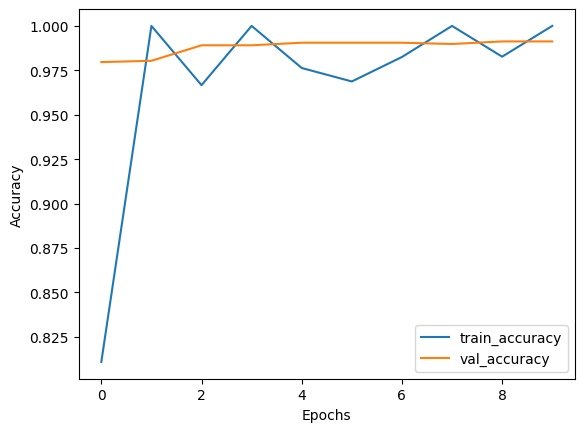

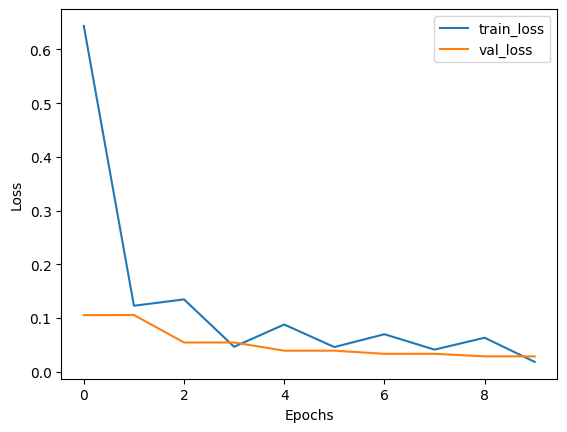

In [16]:
plt.plot(history.history['accuracy'], label='train_accuracy')
plt.plot(history.history['val_accuracy'], label='val_accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

plt.plot(history.history['loss'], label='train_loss')
plt.plot(history.history['val_loss'], label='val_loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

44/44 ━━━━━━━━━━━━━━━━━━━━ 55s 1s/step


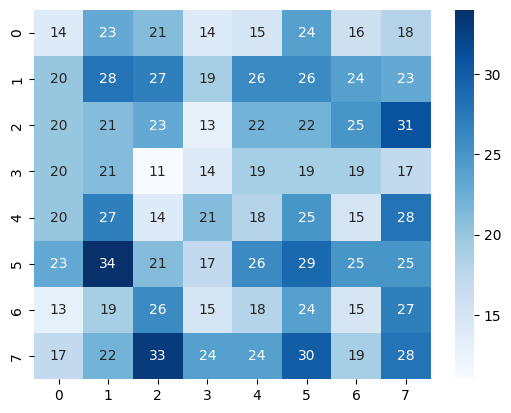

In [18]:
import numpy as np
from sklearn.metrics import confusion_matrix
import seaborn as sns

y_pred = model.predict(validation_generator)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true = validation_generator.classes

cm = confusion_matrix(y_true, y_pred_classes)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.show()

In [19]:
model.save('transfer_learning_natural_images.h5')

from google.colab import files
files.download('transfer_learning_natural_images.h5')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>